/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.8943
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8520
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7565
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7124
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9326
Epoch 6/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7247
Epoch 7/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8492
Epoch 8/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8126
Epoch 9/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9287
Epoch 10/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6779
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


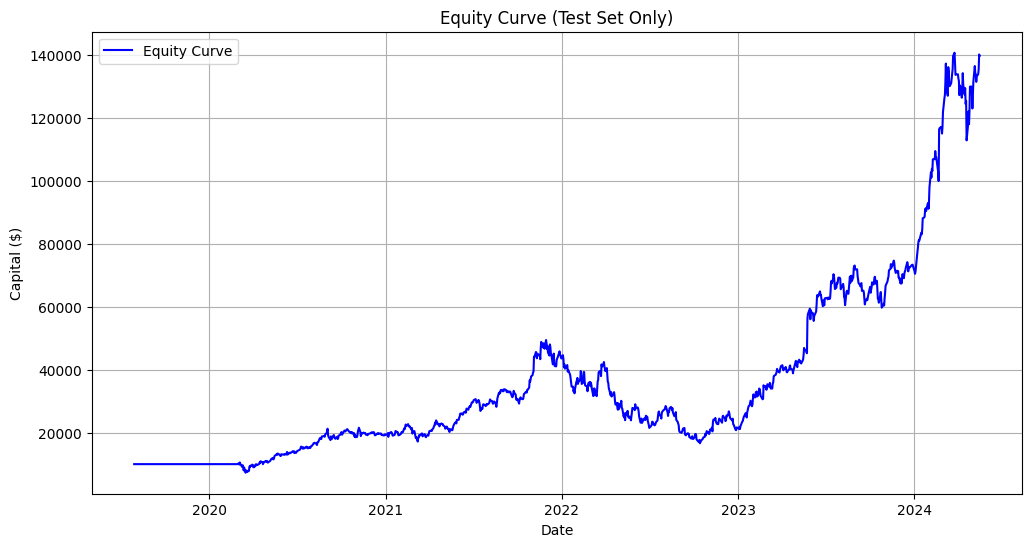

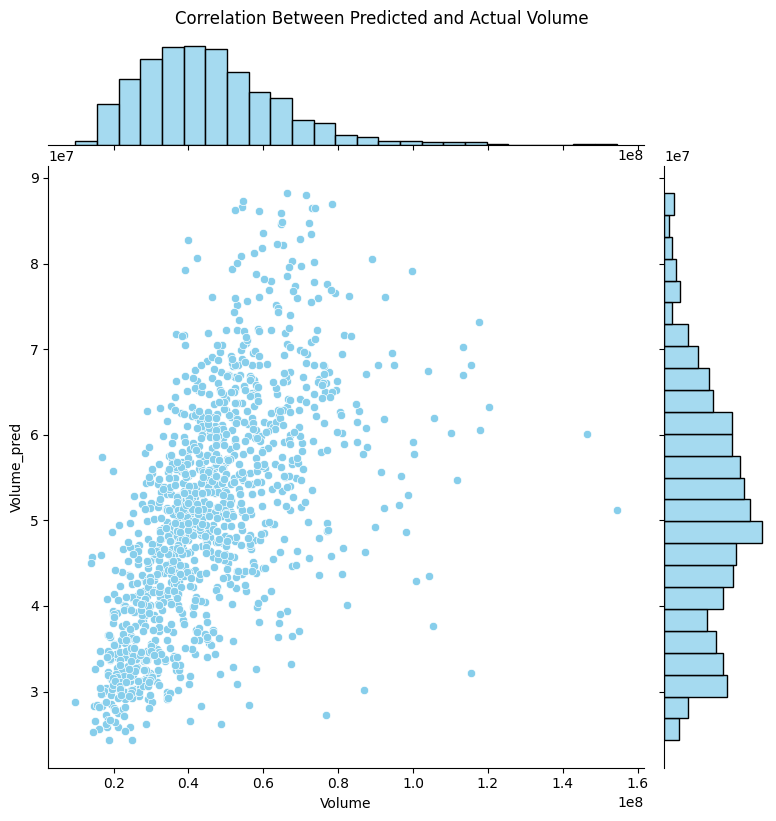

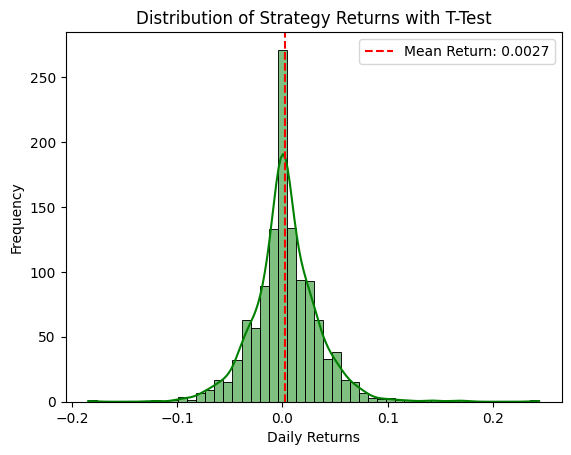

<ipython-input-1-9e814c061762>:183: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Rolling_Sharpe'].fillna(0, inplace=True)


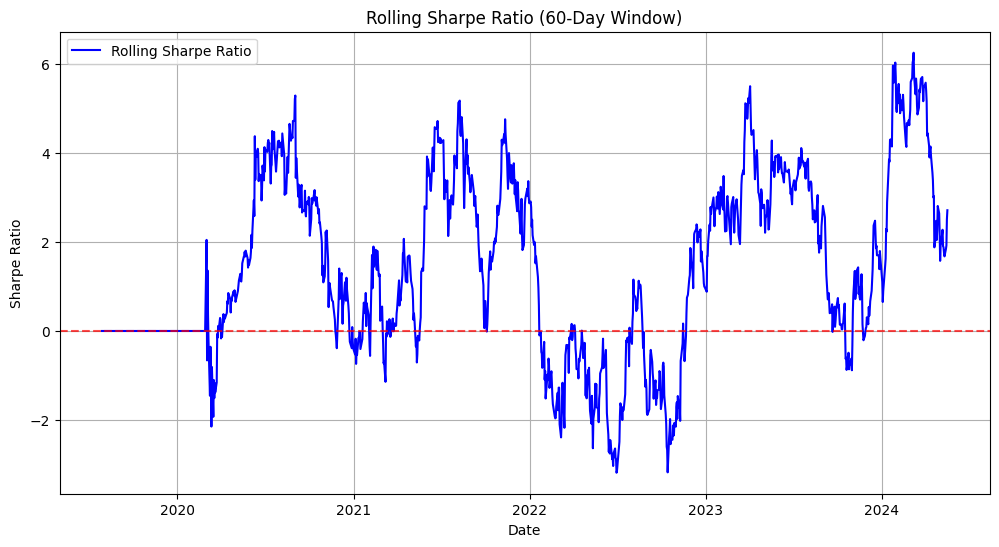

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler

from scipy import stats

csv_file = 'Nvidia Dataset.csv'
df = pd.read_csv(csv_file, parse_dates=['Date'], index_col='Date')
df.sort_index(inplace=True)

df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)

df['return'] = df['Close'].pct_change()
df['volatility'] = df['return'].rolling(10).std()
df.dropna(subset=['return', 'volatility'], inplace=True)

feature_cols = ['Volume', 'return', 'volatility']
target_col = 'Volume'

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

features_raw = df[feature_cols].astype('float32')
target_raw = df[target_col].astype('float32')

features_scaled = feature_scaler.fit_transform(features_raw)
target_scaled = target_scaler.fit_transform(target_raw.values.reshape(-1, 1)).flatten()

dates = df.index

window_size = 10
horizon = 5

split_idx = int(len(features_scaled) * 0.8)
features_train, features_test = features_scaled[:split_idx], features_scaled[split_idx:]
target_train, target_test = target_scaled[:split_idx], target_scaled[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

X_train, y_train, train_dates = [], [], []
X_test, y_test, test_dates = [], [], []

for i in range(window_size, len(features_train) - horizon):
    X_train.append(features_train[i - window_size:i])
    y_train.append(target_train[i + horizon - 1])
    train_dates.append(dates_train[i])

for i in range(window_size, len(features_test) - horizon):
    X_test.append(features_test[i - window_size:i])
    y_test.append(target_test[i + horizon - 1])
    test_dates.append(dates_test[i])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

model = keras.Sequential([
    layers.LSTM(16, activation='tanh', input_shape=(window_size, len(feature_cols))),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=1)

y_pred_test_scaled = model.predict(X_test).squeeze()
y_pred_test = target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

pred_df = pd.DataFrame({'Volume_pred': y_pred_test}, index=test_dates)

df['Volume_pred'] = np.nan
df.loc[test_dates, 'Volume_pred'] = pred_df['Volume_pred']

df_test = df.loc[test_dates].copy()
df_test.dropna(subset=['Volume_pred'], inplace=True)

df_test['Returns'] = df_test['Close'].pct_change()
df_test['SMA_20'] = df_test['Close'].rolling(20).mean()
df_test['SMA_50'] = df_test['Close'].rolling(50).mean()
df_test.dropna(subset=['Returns', 'SMA_20', 'SMA_50'], inplace=True)

df_test['Regime'] = np.where(df_test['SMA_20'] > df_test['SMA_50'], 1, 0)

high_volume_threshold = df_test['Volume_pred'].quantile(0.90)
low_volume_threshold = df_test['Volume_pred'].quantile(0.10)

def generate_signals(row):
    if row['Volume_pred'] > high_volume_threshold and row['Regime'] == 1 and row['Returns'] > 0:
        return 1
    elif row['Volume_pred'] > high_volume_threshold and row['Regime'] == 0 and row['Returns'] < 0:
        return -1
    return 0

df_test['Signal'] = df_test.apply(generate_signals, axis=1)

initial_capital = 10000.0
capital = initial_capital
position = 0.0
entry_price = 0.0

capital_values = [initial_capital]
drawdown_values = [0.0]
peak_capital = initial_capital

for i in range(1, len(df_test)):
    row = df_test.iloc[i]
    close_price = row['Close']
    daily_ret = row['Returns']
    signal = row['Signal']

    if position != 0:
        capital += capital * daily_ret * position

    if position == 0 and signal != 0:
        position = 1.0 if signal == 1 else -1.0
        entry_price = close_price

    if capital > peak_capital:
        peak_capital = capital
    drawdown = (peak_capital - capital) / peak_capital

    capital_values.append(capital)
    drawdown_values.append(drawdown)

while len(capital_values) < len(df_test):
    capital_values.append(capital_values[-1])
    drawdown_values.append(drawdown_values[-1])

df_test['Capital'] = capital_values

returns_ser = df_test['Capital'].pct_change().fillna(0)
sharpe = (returns_ser.mean() / returns_ser.std()) * np.sqrt(252) if returns_ser.std() != 0 else 0

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['Capital'], label='Equity Curve', color='b')
plt.title('Equity Curve (Test Set Only)')
plt.xlabel('Date')
plt.ylabel('Capital ($)')
plt.legend()
plt.grid(True)
plt.show()

sns.jointplot(
    x='Volume',
    y='Volume_pred',
    data=df_test,
    kind='scatter',
    height=8,
    color='skyblue',
    marginal_kws=dict(bins=25, fill=True)
)
plt.suptitle('Correlation Between Predicted and Actual Volume', y=1.02)
plt.show()

returns_ser = df_test['Capital'].pct_change().fillna(0)
sns.histplot(returns_ser, kde=True, bins=50, color='green')
plt.axvline(returns_ser.mean(), color='red', linestyle='--', label=f'Mean Return: {returns_ser.mean():.4f}')
plt.title('Distribution of Strategy Returns with T-Test')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

t_stat, p_val = stats.ttest_1samp(returns_ser.dropna(), 0.0)

rolling_window = 60

df_test['Strategy_Returns'] = df_test['Capital'].pct_change().fillna(0)

df_test['Rolling_Sharpe'] = (
    df_test['Strategy_Returns']
    .rolling(rolling_window)
    .mean()
    / df_test['Strategy_Returns'].rolling(rolling_window).std()
) * np.sqrt(252)

df_test['Rolling_Sharpe'].fillna(0, inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['Rolling_Sharpe'], label='Rolling Sharpe Ratio', color='b')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.7)
plt.title('Rolling Sharpe Ratio (60-Day Window)')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()
